In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
model = CmdStanModel(stan_file='trape3.stan')
fit = model.sample(data='trape_individuals.json', show_console=False, show_progress=True, chains=4, parallel_chains=4)

print(fit.summary())

draws = fit.draws_pd()
draws.to_csv('trape3_draws.csv')
with open('trape3_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

13:38:45 - cmdstanpy - INFO - compiling stan file /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape3.stan to exe file /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape3
13:39:10 - cmdstanpy - INFO - compiled model executable: /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape3
13:39:10 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

13:41:16 - cmdstanpy - INFO - CmdStan done processing.
13:41:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -5.04093e-12, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -2.76733e-12, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'trape3.stan', line 77, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -2.47129e-14, but must be nonnegative! (in 'trape3.stan', l


                     Mean      MCSE     StdDev           5%          50%  \
lp__          7205.450000  0.606823  19.410300  7172.130000  7205.710000   
tau_elp[1]       0.453616  0.004116   0.273085     0.079495     0.415166   
tau_elp[2]       0.730273  0.009794   0.568890     0.047100     0.619579   
tau_elp[3]       0.693143  0.006574   0.400999     0.144684     0.639309   
tau_elp[4]       1.177550  0.009752   0.554488     0.343447     1.137230   
...                   ...       ...        ...          ...          ...   
log_lik[634]    -1.868220  0.008980   0.511312    -2.891610    -1.670340   
log_lik[635]    -1.119330  0.003452   0.166913    -1.455720    -1.055170   
log_lik[636]    -0.555190  0.005507   0.350800    -1.206840    -0.482701   
log_lik[637]    -0.327158  0.006681   0.292131    -0.881634    -0.242277   
log_lik[638]    -0.142275  0.009071   0.232556    -0.579414    -0.057414   

                      95%     N_Eff   N_Eff/s     R_hat  
lp__          7235.790000  1

In [3]:
with open('trape3_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [4]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [5]:
i = 1 # index of individual to extract: 1 to 111
vars = ['lambda', 'tau_elp', 'delta_clinical', 'rho_clinical', 'gamma_clinical']
y = z.posterior.isel(lambda_dim_0=i, tau_elp_dim_0=i, delta_clinical_dim_0=i, rho_clinical_dim_0=i, gamma_clinical_dim_0=i)

Rhat values good

In [6]:
print(az.rhat(y, var_names=vars))

<xarray.Dataset> Size: 80B
Dimensions:               ()
Coordinates:
    tau_elp_dim_0         int64 8B 1
    rho_clinical_dim_0    int64 8B 1
    lambda_dim_0          int64 8B 1
    delta_clinical_dim_0  int64 8B 1
    gamma_clinical_dim_0  int64 8B 1
Data variables:
    lambda                float64 8B 1.001
    tau_elp               float64 8B 1.001
    delta_clinical        float64 8B 1.001
    rho_clinical          float64 8B 1.002
    gamma_clinical        float64 8B 1.0


Effective samples sizes good

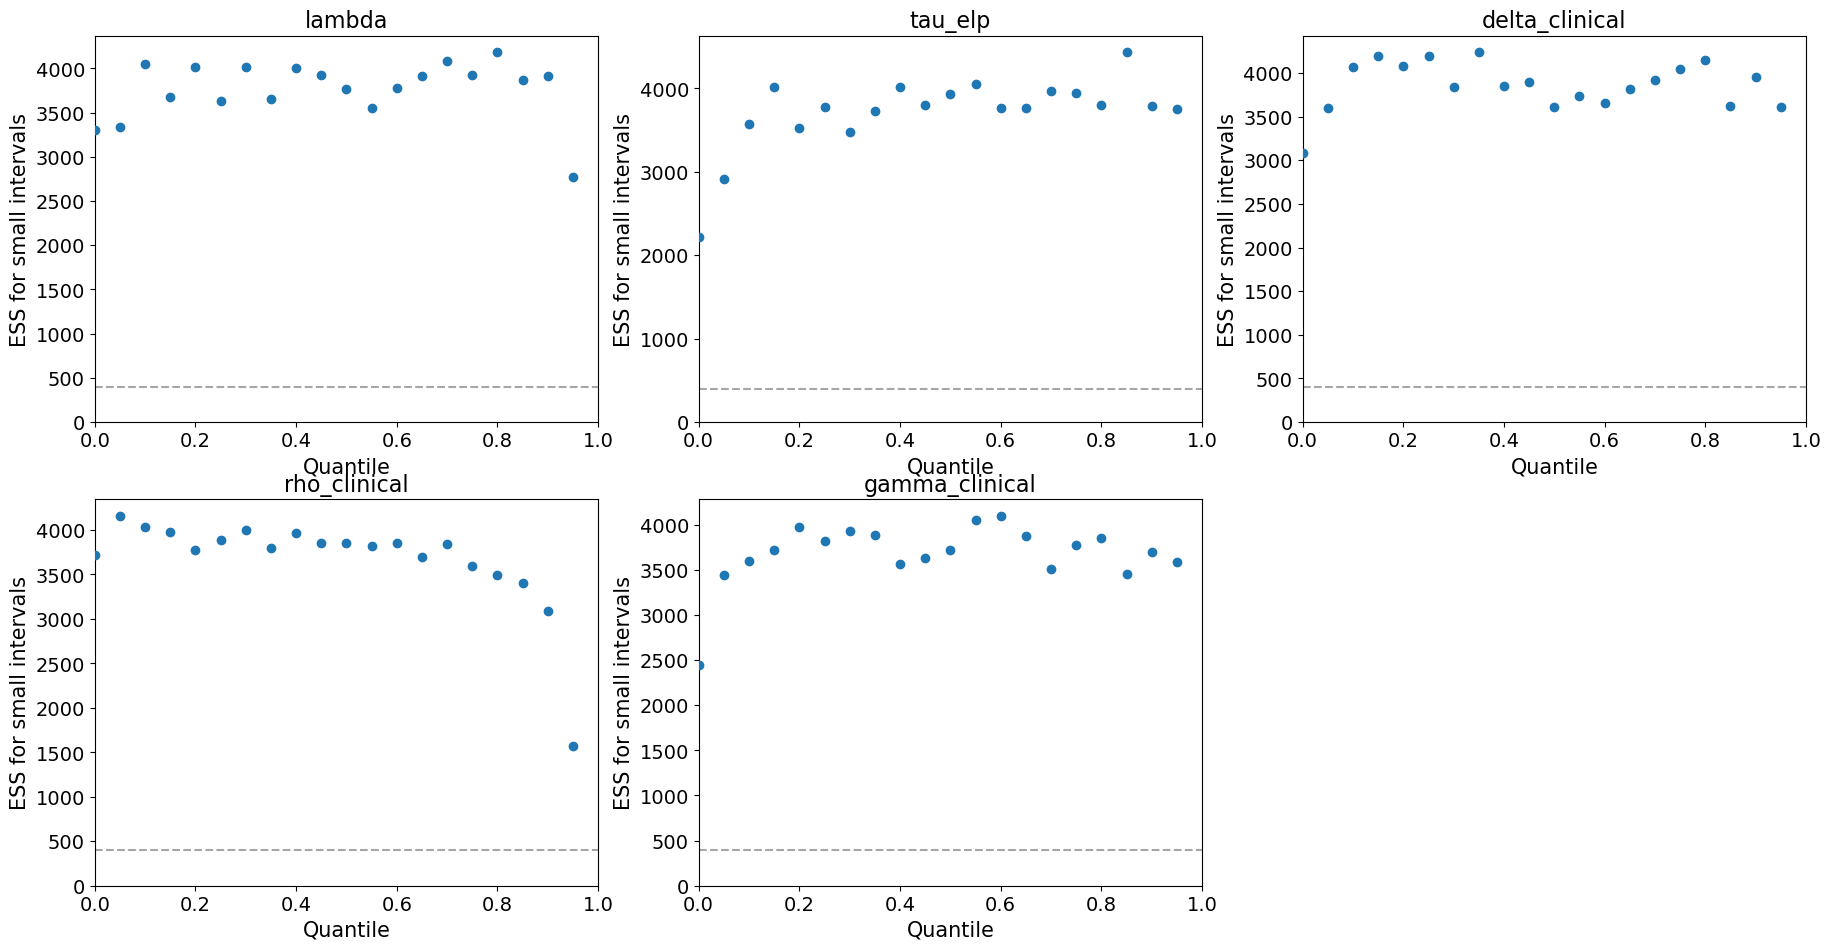

In [7]:
az.plot_ess(y, var_names=vars);

No major autocorrelation

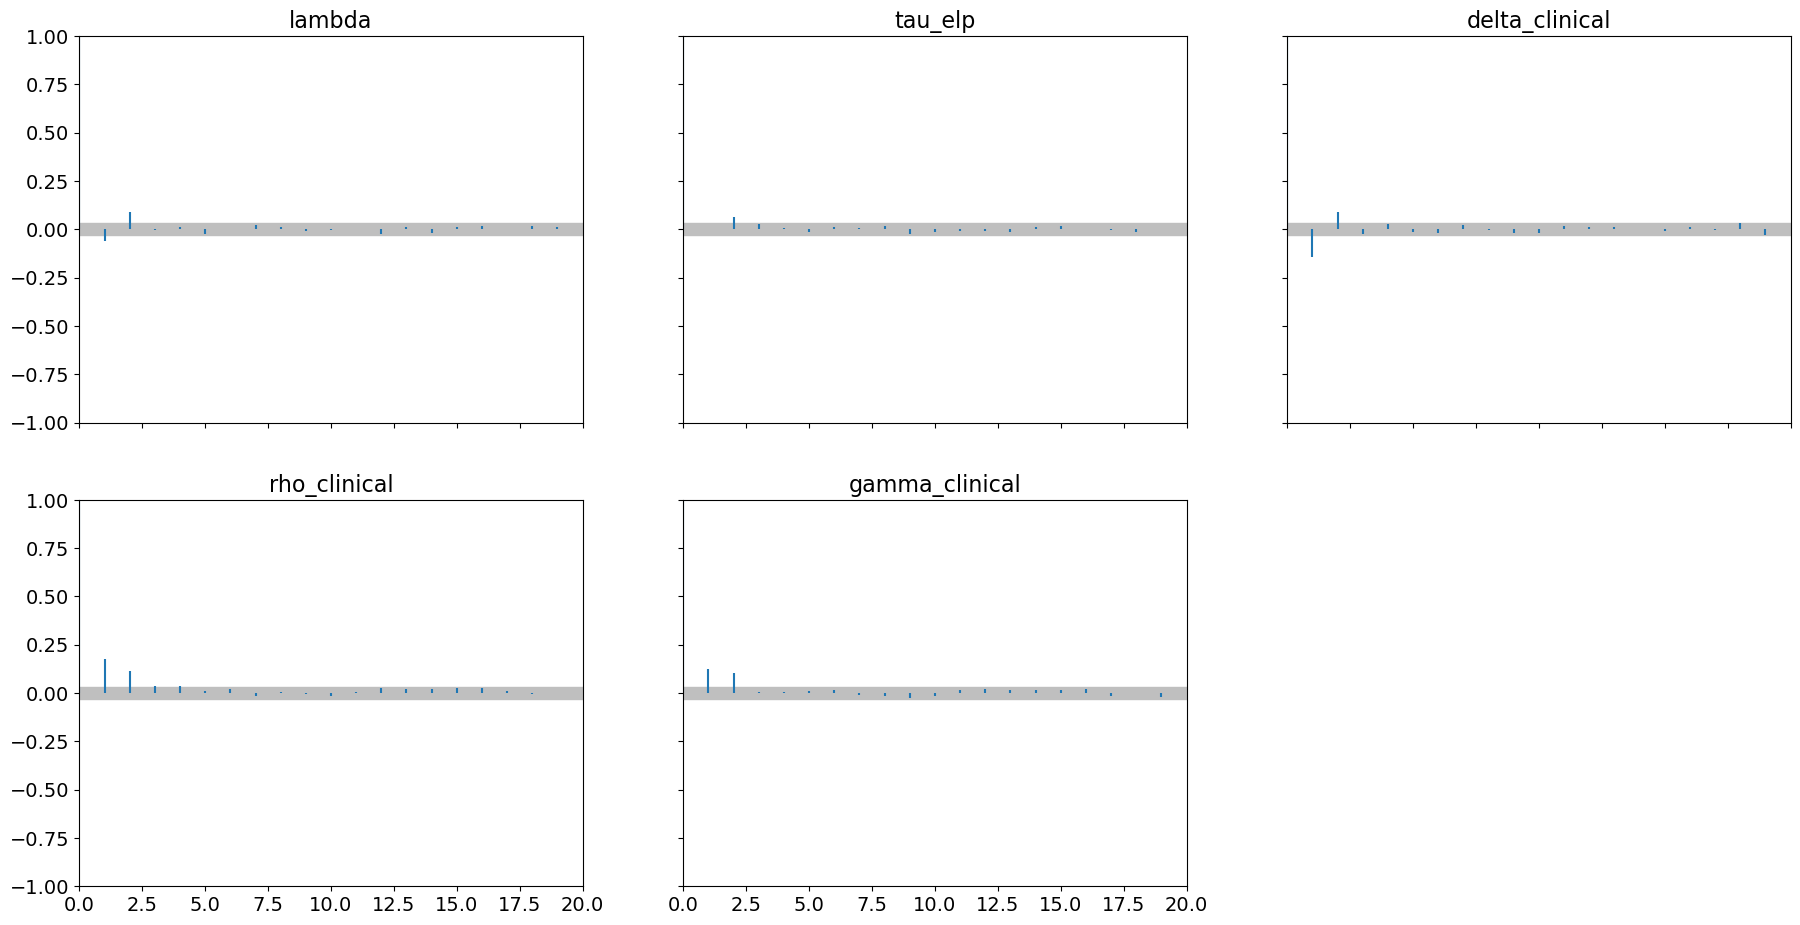

In [8]:
az.plot_autocorr(y, var_names=vars, combined=True, max_lag=20,);

Chains look good

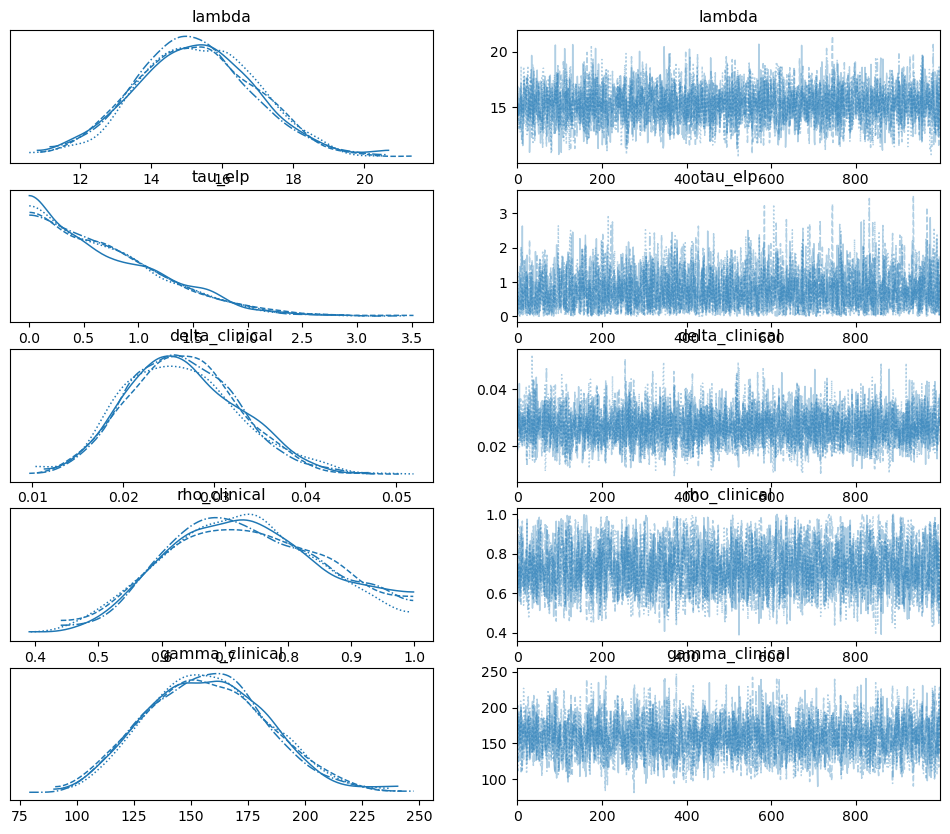

In [9]:
az.plot_trace(y, var_names=vars);

Pair plot reveals identifiability issue between rho and gamma

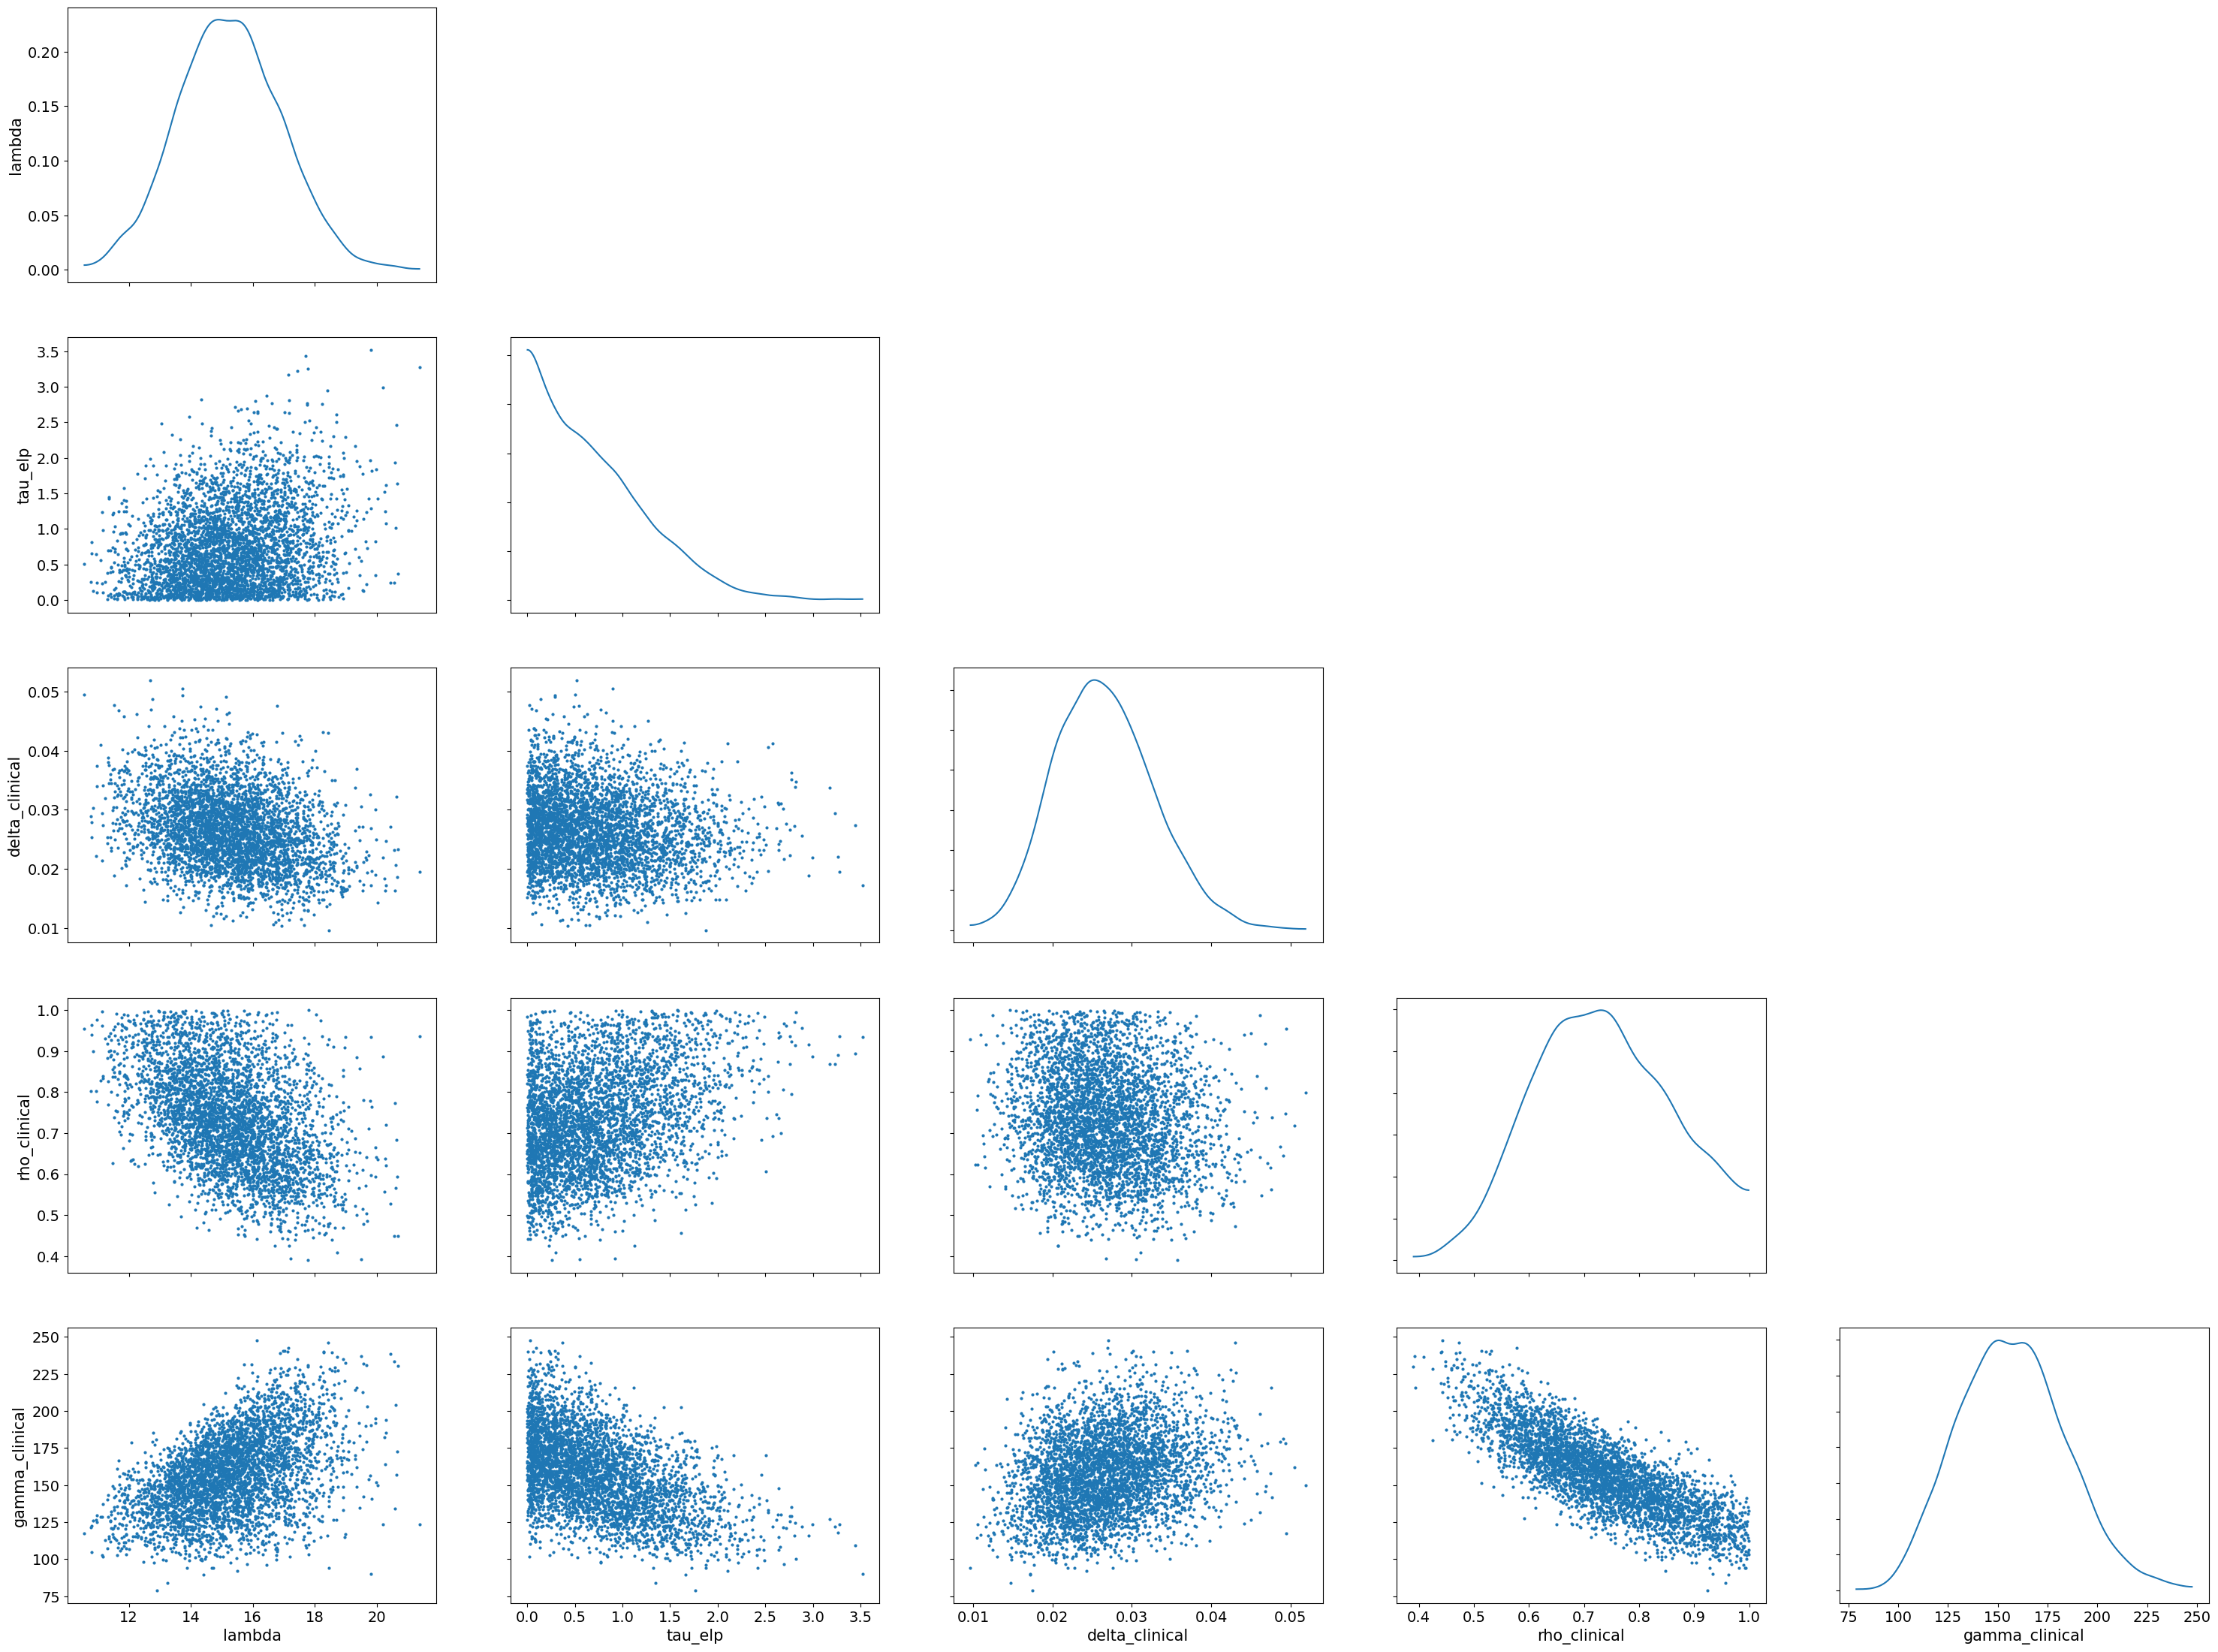

In [10]:
az.plot_pair(y, var_names=vars, marginals=True);